# 🎵 Chinook Customer Support Agent — LangSmith Evaluation

LangGraph ile inşa edilmiş bir müzik mağazası destek botunun **3 farklı evaluation türüyle** test edilmesi:

| # | Tür | Ne ölçer? |
|---|-----|-----------|
| 1 | **Final Response** | Ajandan gelen son yanıtın doğruluğu (LLM-as-judge) |
| 2 | **Trajectory** | Ajanın beklenen adımları sırasıyla izleyip izlemediği |
| 3 | **Single Step** | `intent_classifier` node'unun tek başına doğruluğu |

**Stack:** `langgraph` · `langchain[openai]` · `langsmith` · `tabulate` · Chinook SQLite DB

## 1. Install Dependencies & Configure Environment

In [1]:
%pip install -q -U langgraph "langchain[openai]" langsmith tabulate

/Users/huseyin/Documents/LLM/agentx/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import getpass
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["LANGSMITH_TRACING"] = "true"

def _set_env(var: str) -> None:
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("LANGSMITH_API_KEY")
_set_env("OPENAI_API_KEY")
# Optional: Anthropic for QA agent (claude-sonnet)
_set_env("ANTHROPIC_API_KEY")

print("✅ Environment configured")

✅ Environment configured


## 2. Download and Explore the Chinook Database

In [3]:
import requests
import sqlite3

DB_PATH = "chinook.db"

url = "https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db"
response = requests.get(url)
if response.status_code == 200:
    with open(DB_PATH, "wb") as f:
        f.write(response.content)
    print("✅ chinook.db downloaded")
else:
    print(f"❌ Download failed: HTTP {response.status_code}")

# Verify
conn = sqlite3.connect(DB_PATH)
rows = conn.execute("SELECT ArtistId, Name FROM Artist LIMIT 10").fetchall()
conn.close()
print("\nSample artists:")
for r in rows:
    print(f"  {r[0]:>3}. {r[1]}")

✅ chinook.db downloaded

Sample artists:
    1. AC/DC
    2. Accept
    3. Aerosmith
    4. Alanis Morissette
    5. Alice In Chains
    6. Antônio Carlos Jobim
    7. Apocalyptica
    8. Audioslave
    9. BackBeat
   10. Billy Cobham


## 3. Define SQL Helper Functions (Refund & Lookup)

In [4]:
def _refund(
    invoice_id: int | None,
    invoice_line_ids: list[int] | None,
    mock: bool = False,
) -> float:
    """Delete Invoice/InvoiceLine rows and return total refunded amount.
    If mock=True, calculates the amount without touching the DB."""
    if invoice_id is None and invoice_line_ids is None:
        return 0.0

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    total = 0.0
    try:
        if invoice_id is not None:
            row = cursor.execute(
                "SELECT Total FROM Invoice WHERE InvoiceId = ?", (invoice_id,)
            ).fetchone()
            if row:
                total += row[0]
            if not mock:
                cursor.execute("DELETE FROM InvoiceLine WHERE InvoiceId = ?", (invoice_id,))
                cursor.execute("DELETE FROM Invoice WHERE InvoiceId = ?", (invoice_id,))

        if invoice_line_ids:
            placeholders = ",".join("?" * len(invoice_line_ids))
            row = cursor.execute(
                f"SELECT SUM(UnitPrice * Quantity) FROM InvoiceLine WHERE InvoiceLineId IN ({placeholders})",
                invoice_line_ids,
            ).fetchone()
            if row and row[0]:
                total += row[0]
            if not mock:
                cursor.execute(
                    f"DELETE FROM InvoiceLine WHERE InvoiceLineId IN ({placeholders})",
                    invoice_line_ids,
                )
        conn.commit()
    except sqlite3.Error as e:
        conn.rollback()
        raise e
    finally:
        conn.close()
    return float(total)


def _lookup(
    customer_first_name: str,
    customer_last_name: str,
    customer_phone: str,
    track_name: str | None = None,
    album_title: str | None = None,
    artist_name: str | None = None,
    purchase_date_iso_8601: str | None = None,
) -> list[dict]:
    """Return purchase records matching the given customer + optional filters."""
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    query = """
        SELECT il.InvoiceLineId, t.Name, art.Name, i.InvoiceDate, il.Quantity, il.UnitPrice
        FROM InvoiceLine il
        JOIN Invoice i   ON il.InvoiceId  = i.InvoiceId
        JOIN Customer c  ON i.CustomerId  = c.CustomerId
        JOIN Track t     ON il.TrackId    = t.TrackId
        JOIN Album alb   ON t.AlbumId     = alb.AlbumId
        JOIN Artist art  ON alb.ArtistId  = art.ArtistId
        WHERE c.FirstName = ? AND c.LastName = ? AND c.Phone = ?
    """
    params: list = [customer_first_name, customer_last_name, customer_phone]

    if track_name:
        query += " AND t.Name = ?"
        params.append(track_name)
    if album_title:
        query += " AND alb.Title = ?"
        params.append(album_title)
    if artist_name:
        query += " AND art.Name = ?"
        params.append(artist_name)
    if purchase_date_iso_8601:
        query += " AND date(i.InvoiceDate) = date(?)"
        params.append(purchase_date_iso_8601)

    rows = cursor.execute(query, params).fetchall()
    conn.close()

    return [
        {
            "invoice_line_id": r[0],
            "track_name": r[1],
            "artist_name": r[2],
            "purchase_date": r[3],
            "quantity_purchased": r[4],
            "price_per_unit": r[5],
        }
        for r in rows
    ]


print("✅ SQL helpers defined")

✅ SQL helpers defined


## 4. Build the Refund Subgraph

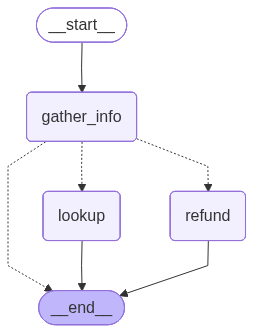

✅ refund_graph compiled


In [5]:
import json
from typing import Literal

from langchain.chat_models import init_chat_model
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, StateGraph
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.types import Command
from tabulate import tabulate
from typing_extensions import Annotated, TypedDict


# ── State ────────────────────────────────────────────────────────────────────
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    followup: str | None
    invoice_id: int | None
    invoice_line_ids: list[int] | None
    customer_first_name: str | None
    customer_last_name: str | None
    customer_phone: str | None
    track_name: str | None
    album_title: str | None
    artist_name: str | None
    purchase_date_iso_8601: str | None


# ── Extraction schema ────────────────────────────────────────────────────────
class PurchaseInformation(TypedDict):
    """Known purchase info. Leave fields null if unknown — do NOT invent values."""
    invoice_id: int | None
    invoice_line_ids: list[int] | None
    customer_first_name: str | None
    customer_last_name: str | None
    customer_phone: str | None
    track_name: str | None
    album_title: str | None
    artist_name: str | None
    purchase_date_iso_8601: str | None
    followup: Annotated[
        str | None,
        ...,
        "Ask the user for required info if missing (first name, last name, phone or invoice IDs).",
    ]


gather_info_instructions = (
    "You are managing an online music store. "
    "Help customers get refunds by extracting their purchase info. "
    "Required for lookup: first name, last name, phone. "
    "Required for direct refund: invoice_id or invoice_line_ids. "
    "If missing, ask the user."
)

info_llm = init_chat_model("gpt-4.1-mini").with_structured_output(
    PurchaseInformation, method="json_schema", include_raw=True
)


# ── Nodes ────────────────────────────────────────────────────────────────────
async def gather_info(state: State) -> Command[Literal["lookup", "refund", END]]:
    info = await info_llm.ainvoke(
        [{"role": "system", "content": gather_info_instructions}, *state["messages"]]
    )
    parsed = info["parsed"]
    if any(parsed[k] for k in ("invoice_id", "invoice_line_ids")):
        goto = "refund"
    elif all(parsed[k] for k in ("customer_first_name", "customer_last_name", "customer_phone")):
        goto = "lookup"
    else:
        goto = END
    return Command(update={"messages": [info["raw"]], **parsed}, goto=goto)


def refund(state: State, config: RunnableConfig) -> dict:
    mock = config.get("configurable", {}).get("env", "prod") == "test"
    total = _refund(state["invoice_id"], state["invoice_line_ids"], mock=mock)
    msg = f"You have been refunded a total of: ${total:.2f}. Is there anything else I can help with?"
    return {"messages": [{"role": "assistant", "content": msg}], "followup": msg}


def lookup(state: State) -> dict:
    results = _lookup(
        state["customer_first_name"],
        state["customer_last_name"],
        state["customer_phone"],
        state["track_name"],
        state["album_title"],
        state["artist_name"],
        state["purchase_date_iso_8601"],
    )
    if not results:
        msg = "No purchases found with the provided information. Please double-check your details."
        followup = msg
    else:
        msg = f"Which purchase would you like refunded?\n\n```json\n{json.dumps(results, indent=2)}\n```"
        followup = f"Which purchase would you like refunded?\n\n{tabulate(results, headers='keys')}"
    return {
        "messages": [{"role": "assistant", "content": msg}],
        "followup": followup,
        "invoice_line_ids": [r["invoice_line_id"] for r in results],
    }


# ── Build graph ───────────────────────────────────────────────────────────────
_builder = StateGraph(State)
_builder.add_node(gather_info)
_builder.add_node(refund)
_builder.add_node(lookup)
_builder.set_entry_point("gather_info")
_builder.add_edge("lookup", END)
_builder.add_edge("refund", END)
refund_graph = _builder.compile()

from IPython.display import Image, display
display(Image(refund_graph.get_graph().draw_mermaid_png()))
print("✅ refund_graph compiled")

## 5. Build the Question Answering Subgraph

✅ Vector stores built


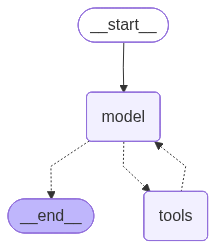

✅ qa_graph compiled


In [6]:
from langchain.embeddings import init_embeddings
from langchain.tools import tool
from langchain_core.vectorstores import InMemoryVectorStore
from langchain.agents import create_agent


def index_fields() -> tuple[InMemoryVectorStore, InMemoryVectorStore, InMemoryVectorStore]:
    """Build in-memory vector stores for tracks, artists, and albums."""
    conn = sqlite3.connect(DB_PATH)
    try:
        tracks  = [r[0] for r in conn.execute("SELECT Name FROM Track").fetchall()]
        artists = [r[0] for r in conn.execute("SELECT Name FROM Artist").fetchall()]
        albums  = [r[0] for r in conn.execute("SELECT Title FROM Album").fetchall()]
    finally:
        conn.close()

    emb = init_embeddings("openai:text-embedding-3-small")
    t_store, ar_store, al_store = (
        InMemoryVectorStore(emb),
        InMemoryVectorStore(emb),
        InMemoryVectorStore(emb),
    )
    t_store.add_texts(tracks)
    ar_store.add_texts(artists)
    al_store.add_texts(albums)
    return t_store, ar_store, al_store


track_store, artist_store, album_store = index_fields()
print("✅ Vector stores built")


@tool
def lookup_track(
    track_name: str | None = None,
    album_title: str | None = None,
    artist_name: str | None = None,
) -> list[dict]:
    """Look up tracks in the Chinook DB. Returns list of {track_name, artist_name, album_name}."""
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT DISTINCT t.Name, ar.Name, al.Title
        FROM Track t
        JOIN Album al  ON t.AlbumId   = al.AlbumId
        JOIN Artist ar ON al.ArtistId = ar.ArtistId
        WHERE 1=1
    """
    params: list = []
    if track_name:
        track_name = track_store.similarity_search(track_name, k=1)[0].page_content
        query += " AND t.Name LIKE ?"
        params.append(f"%{track_name}%")
    if album_title:
        album_title = album_store.similarity_search(album_title, k=1)[0].page_content
        query += " AND al.Title LIKE ?"
        params.append(f"%{album_title}%")
    if artist_name:
        artist_name = artist_store.similarity_search(artist_name, k=1)[0].page_content
        query += " AND ar.Name LIKE ?"
        params.append(f"%{artist_name}%")
    rows = conn.execute(query, params).fetchall()
    conn.close()
    return [{"track_name": r[0], "artist_name": r[1], "album_name": r[2]} for r in rows]


@tool
def lookup_album(
    track_name: str | None = None,
    album_title: str | None = None,
    artist_name: str | None = None,
) -> list[dict]:
    """Look up albums in the Chinook DB. Returns list of {album_name, artist_name}."""
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT DISTINCT al.Title, ar.Name
        FROM Album al
        JOIN Artist ar ON al.ArtistId = ar.ArtistId
        LEFT JOIN Track t ON t.AlbumId = al.AlbumId
        WHERE 1=1
    """
    params: list = []
    if track_name:
        query += " AND t.Name LIKE ?"
        params.append(f"%{track_name}%")
    if album_title:
        query += " AND al.Title LIKE ?"
        params.append(f"%{album_title}%")
    if artist_name:
        query += " AND ar.Name LIKE ?"
        params.append(f"%{artist_name}%")
    rows = conn.execute(query, params).fetchall()
    conn.close()
    return [{"album_name": r[0], "artist_name": r[1]} for r in rows]


@tool
def lookup_artist(
    track_name: str | None = None,
    album_title: str | None = None,
    artist_name: str | None = None,
) -> list[str]:
    """Look up artist names in the Chinook DB."""
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT DISTINCT ar.Name
        FROM Artist ar
        LEFT JOIN Album al ON al.ArtistId = ar.ArtistId
        LEFT JOIN Track t  ON t.AlbumId   = al.AlbumId
        WHERE 1=1
    """
    params: list = []
    if track_name:
        query += " AND t.Name LIKE ?"
        params.append(f"%{track_name}%")
    if album_title:
        query += " AND al.Title LIKE ?"
        params.append(f"%{album_title}%")
    if artist_name:
        query += " AND ar.Name LIKE ?"
        params.append(f"%{artist_name}%")
    rows = conn.execute(query, params).fetchall()
    conn.close()
    return [r[0] for r in rows]


qa_llm   = init_chat_model("gpt-4.1-mini")   # swap to claude-sonnet if available
qa_graph = create_agent(qa_llm, [lookup_track, lookup_artist, lookup_album])

display(Image(qa_graph.get_graph(xray=True).draw_mermaid_png()))
print("✅ qa_graph compiled")

## 6. Build the Parent Agent Graph

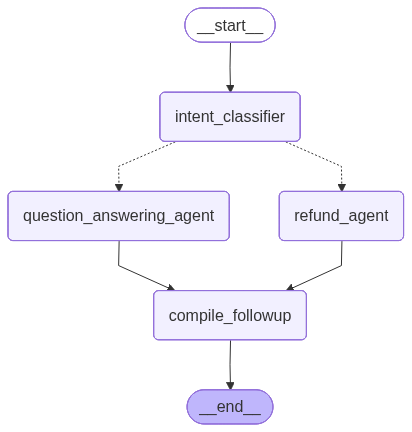

✅ Parent graph compiled


In [7]:
class UserIntent(TypedDict):
    """User's current intent."""
    intent: Literal["refund", "question_answering"]


router_llm = init_chat_model("gpt-4.1-mini").with_structured_output(
    UserIntent, method="json_schema", strict=True
)

route_instructions = (
    "You manage an online music store. "
    "Classify the user's intent as 'refund' (they want money back) "
    "or 'question_answering' (they have a general music question). "
    "Return ONLY the intent key — do NOT respond to the user."
)


async def intent_classifier(
    state: State,
) -> Command[Literal["refund_agent", "question_answering_agent"]]:
    result = await router_llm.ainvoke(
        [{"role": "system", "content": route_instructions}, *state["messages"]]
    )
    return Command(goto=result["intent"] + "_agent")


def compile_followup(state: State) -> dict:
    if not state.get("followup"):
        return {"followup": state["messages"][-1].content}
    return {}


# Wire parent graph
_pb = StateGraph(State)
_pb.add_node(intent_classifier)
_pb.add_node("refund_agent", refund_graph)
_pb.add_node("question_answering_agent", qa_graph)
_pb.add_node(compile_followup)
_pb.set_entry_point("intent_classifier")
_pb.add_edge("refund_agent", "compile_followup")
_pb.add_edge("question_answering_agent", "compile_followup")
_pb.add_edge("compile_followup", END)
graph = _pb.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
print("✅ Parent graph compiled")

## 7. Smoke Test the Agent

In [8]:
# QA route
state = await graph.ainvoke(
    {"messages": [{"role": "user", "content": "what james brown songs do you have"}]}
)
print("🎵 QA response:")
print(state["followup"])

print("\n" + "─" * 60 + "\n")

# Refund route
state = await graph.ainvoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "my name is Aaron Mitchell and my number is +1 (204) 452-6452. "
                    "I bought some songs by Led Zeppelin that I'd like refunded."
                ),
            }
        ]
    }
)
print("💳 Refund response:")
print(state["followup"])

🎵 QA response:
Here are some James Brown songs available:

1. Please Please Please
2. Think
3. Night Train
4. Out Of Sight
5. Papa's Got A Brand New Bag Pt.1
6. I Got You (I Feel Good)
7. It's A Man's Man's Man's World
8. Cold Sweat
9. Say It Loud, I'm Black And I'm Proud Pt.1
10. Get Up (I Feel Like Being A) Sex Machine
11. Hey America
12. Make It Funky Pt.1
13. I'm A Greedy Man Pt.1
14. Get On The Good Foot
15. Get Up Offa That Thing
16. It's Too Funky In Here
17. Living In America
18. I'm Real
19. Hot Pants Pt.1
20. Soul Power (Live)

All these tracks are from the album "Sex Machine." Would you like more details about any specific song or album?

────────────────────────────────────────────────────────────

💳 Refund response:
Which purchase would you like refunded?

  invoice_line_id  track_name                        artist_name    purchase_date          quantity_purchased    price_per_unit
-----------------  --------------------------------  -------------  -------------------  ---

## 8. Create the E2E Evaluation Dataset

In [12]:
from langsmith import Client

client = Client()

E2E_DATASET = "Chinook Customer Service Bot: E2E"

e2e_examples = [
    {
        "inputs": {"question": "How many songs do you have by James Brown"},
        "outputs": {
            "response": "We have 20 songs by James Brown",
            "trajectory": ["question_answering_agent", "lookup_track"],
        },
    },
    {
        "inputs": {"question": "My name is Aaron Mitchell and I'd like a refund."},
        "outputs": {
            "response": "I need some more information. Please specify your phone number, invoice ID, or invoice line IDs.",
            "trajectory": ["refund_agent"],
        },
    },
    {
        "inputs": {
            "question": "My name is Aaron Mitchell and I'd like a refund on my Led Zeppelin purchases. My number is +1 (204) 452-6452"
        },
        "outputs": {
            "response": (
                "Which of the following purchases would you like to be refunded for?\n\n"
                "  invoice_line_id  track_name                        artist_name    purchase_date          quantity_purchased    price_per_unit\n"
                "-----------------  --------------------------------  -------------  -------------------  --------------------  ----------------\n"
                "              267  How Many More Times               Led Zeppelin   2009-08-06 00:00:00                     1              0.99\n"
                "              268  What Is And What Should Never Be  Led Zeppelin   2009-08-06 00:00:00                     1              0.99"
            ),
            "trajectory": ["refund_agent", "lookup"],
        },
    },
    {
        "inputs": {"question": "Who recorded Wish You Were Here again? What other albums do you have?"},
        "outputs": {
            "response": "Wish You Were Here is an album by Pink Floyd",
            "trajectory": ["question_answering_agent", "lookup_album"],
        },
    },
    {
        "inputs": {"question": "I want a full refund for invoice 237"},
        "outputs": {
            "response": "You have been refunded $0.99.",
            "trajectory": ["refund_agent", "refund"],
        },
    },
]

if not client.has_dataset(dataset_name=E2E_DATASET):
    ds = client.create_dataset(E2E_DATASET)
    client.create_examples(dataset_id=ds.id, examples=e2e_examples)
    print(f"✅ Dataset created: {E2E_DATASET}")
else:
    print(f"ℹ️  Dataset already exists: {E2E_DATASET}")

ℹ️  Dataset already exists: Chinook Customer Service Bot: E2E


## 9. Define the LLM-as-Judge Final Response Evaluator

In [13]:
grader_instructions = """You are a teacher grading a quiz.

Given a QUESTION, the GROUND TRUTH RESPONSE, and the STUDENT RESPONSE:
1. Grade based ONLY on factual accuracy relative to the ground truth.
2. Flag any conflicting statements.
3. Extra correct info is acceptable.

Correctness: True = meets all criteria. False = does not."""


class Grade(TypedDict):
    """Grading schema."""
    reasoning: Annotated[str, ..., "Step-by-step reasoning for the grade."]
    is_correct: Annotated[bool, ..., "True if the student response is mostly correct."]


grader_llm = init_chat_model("gpt-4.1-mini", temperature=0).with_structured_output(
    Grade, method="json_schema", strict=True
)


async def final_answer_correct(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """LLM-as-judge: is the agent's final response factually equivalent to the ground truth?"""
    user = (
        f"QUESTION: {inputs['question']}\n"
        f"GROUND TRUTH RESPONSE: {reference_outputs['response']}\n"
        f"STUDENT RESPONSE: {outputs['response']}"
    )
    grade = await grader_llm.ainvoke(
        [{"role": "system", "content": grader_instructions}, {"role": "user", "content": user}]
    )
    return grade["is_correct"]


print("✅ LLM-as-judge evaluator defined")

✅ LLM-as-judge evaluator defined


## 10. Run Final Response Evaluation

In [15]:
async def run_graph_e2e(inputs: dict) -> dict:
    """Invoke the graph and return the final followup response.
    Uses config env=test so refunds are mocked (no actual DB writes)."""
    result = await graph.ainvoke(
        {"messages": [{"role": "user", "content": inputs["question"]}]},
        config={"configurable": {"env": "test"}},
    )
    return {"response": result["followup"]}


e2e_results = await client.aevaluate(
    run_graph_e2e,
    data=E2E_DATASET,
    evaluators=[final_answer_correct],
    experiment_prefix="chinook-e2e-final-response",
    num_repetitions=1,
    max_concurrency=4,
)
e2e_results.to_pandas()

View the evaluation results for experiment: 'chinook-e2e-final-response-962b0d02' at:
https://smith.langchain.com/o/378a72ed-098a-4298-9931-7e1696a11886/datasets/e2af0c8b-c0a1-4022-9b26-73a3dd97f439/compare?selectedSessions=2dbce154-f69c-4986-a44f-fcec62305430




5it [00:06,  1.31s/it]


,inputs.question,outputs.response,error,reference.response,reference.trajectory,feedback.final_answer_correct,execution_time,example_id,id
0,I want a full refund for invoice 237,You have been refunded a total of: $0.99. Is t...,None,You have been refunded $0.99.,"[refund_agent, refund]",True,1.995726,384b90ac-f71a-44b8-b57f-a5a304da5af1,019c7635-7ec4-76a1-94f6-19cb56619782
1,My name is Aaron Mitchell and I'd like a refun...,No purchases found with the provided informati...,None,Which of the following purchases would you lik...,"[refund_agent, lookup]",False,2.078287,5a4e75a8-2ebf-4155-a3b2-b495543fd7ef,019c7635-7ecd-7602-ab4b-46af6745ca53
2,How many songs do you have by James Brown,There are 20 songs by James Brown in the colle...,None,We have 20 songs by James Brown,"[question_answering_agent, lookup_track]",True,3.842082,104c2660-76f7-4f14-b9b9-9e43b9aa7eac,019c7635-7ebe-77d2-b8ff-77d784752339
3,Who recorded Wish You Were Here again? What ot...,I couldn't find a recorded album specifically ...,None,Wish You Were Here is an album by Pink Floyd,"[question_answering_agent, lookup_album]",False,3.820773,802f28c4-ae76-4006-a433-93fc8eb1acf8,019c7635-7ed3-73e1-9df4-758770f61c90
4,My name is Aaron Mitchell and I'd like a refund.,Please provide your phone number and either yo...,None,I need some more information. Please specify y...,[refund_agent],True,1.936740,aa88e74d-b9cf-45e8-8927-d5f3bc3c6a31,019c7635-8bf5-7283-9872-337530592a4c


## 11. Define the Trajectory Evaluator

In [16]:
def trajectory_subsequence(outputs: dict, reference_outputs: dict) -> float:
    """Score = fraction of expected trajectory steps that appear (in order) in actual trajectory.
    Returns 0.0 if actual is shorter than expected."""
    ref = reference_outputs.get("trajectory", [])
    actual = outputs.get("trajectory", [])

    if len(ref) > len(actual):
        return 0.0

    i = j = 0
    while i < len(ref) and j < len(actual):
        if ref[i] == actual[j]:
            i += 1
        j += 1

    return i / len(ref) if ref else 1.0


print("✅ Trajectory evaluator defined")

✅ Trajectory evaluator defined


## 12. Run Trajectory Evaluation

In [18]:
async def run_graph_trajectory(inputs: dict) -> dict:
    """Stream the graph and collect the node/tool trajectory."""
    trajectory: list[str] = []
    async for _ns, chunk in graph.astream(
        {"messages": [{"role": "user", "content": inputs["question"]}]},
        subgraphs=True,
        stream_mode="debug",
    ):
        if chunk.get("type") == "task":
            node_name = chunk["payload"]["name"]
            trajectory.append(node_name)
            # Capture tool calls inside the 'tools' node — guard for missing keys
            if node_name == "tools":
                payload_input = chunk["payload"].get("input", {})
                msgs = payload_input.get("messages", [])
                if msgs:
                    last_msg = msgs[-1]
                    tool_calls = getattr(last_msg, "tool_calls", [])
                    for tc in tool_calls:
                        trajectory.append(tc["name"])
    return {"trajectory": trajectory}


trajectory_results = await client.aevaluate(
    run_graph_trajectory,
    data=E2E_DATASET,
    evaluators=[trajectory_subsequence],
    experiment_prefix="chinook-e2e-trajectory",
    num_repetitions=1,
    max_concurrency=4,
)
trajectory_results.to_pandas()


View the evaluation results for experiment: 'chinook-e2e-trajectory-2bf10a99' at:
https://smith.langchain.com/o/378a72ed-098a-4298-9931-7e1696a11886/datasets/e2af0c8b-c0a1-4022-9b26-73a3dd97f439/compare?selectedSessions=01b7fa30-19c8-42ff-bf09-db52e4eac3fd




5it [00:05,  1.15s/it]



,inputs.question,outputs.trajectory,error,reference.response,reference.trajectory,feedback.trajectory_subsequence,execution_time,example_id,id
0,My name is Aaron Mitchell and I'd like a refun...,"[intent_classifier, refund_agent, gather_info,...",None,Which of the following purchases would you lik...,"[refund_agent, lookup]",1.0,2.023852,5a4e75a8-2ebf-4155-a3b2-b495543fd7ef,019c7637-d7c2-72d1-a1cb-03b38b83f519
1,I want a full refund for invoice 237,"[intent_classifier, refund_agent, gather_info,...",None,You have been refunded $0.99.,"[refund_agent, refund]",1.0,3.693667,384b90ac-f71a-44b8-b57f-a5a304da5af1,019c7637-d7c0-7eb0-9b33-7481809d5a05
2,How many songs do you have by James Brown,"[intent_classifier, question_answering_agent, ...",None,We have 20 songs by James Brown,"[question_answering_agent, lookup_track]",0.5,4.237519,104c2660-76f7-4f14-b9b9-9e43b9aa7eac,019c7637-d7bf-7120-a155-ebda02cdbbc4
3,Who recorded Wish You Were Here again? What ot...,"[intent_classifier, question_answering_agent, ...",None,Wish You Were Here is an album by Pink Floyd,"[question_answering_agent, lookup_album]",0.5,5.266856,802f28c4-ae76-4006-a433-93fc8eb1acf8,019c7637-d7cf-7082-9b6f-2d734d9772c1
4,My name is Aaron Mitchell and I'd like a refund.,"[intent_classifier, refund_agent, gather_info,...",None,I need some more information. Please specify y...,[refund_agent],1.0,3.693916,aa88e74d-b9cf-45e8-8927-d5f3bc3c6a31,019c7637-dfae-77e1-94a2-75dc639f166b


## 13. Create the Intent Classifier Dataset

In [19]:
INTENT_DATASET = "Chinook Customer Service Bot: Intent Classifier"

intent_examples = [
    {
        "inputs": {
            "messages": [{"role": "user", "content": "i bought some tracks recently and i dont like them"}]
        },
        "outputs": {"route": "refund_agent"},
    },
    {
        "inputs": {
            "messages": [{"role": "user", "content": "I was thinking of purchasing some Rolling Stones tunes, any recommendations?"}]
        },
        "outputs": {"route": "question_answering_agent"},
    },
    {
        "inputs": {
            "messages": [
                {"role": "user", "content": "i want a refund on purchase 237"},
                {"role": "assistant", "content": "I've refunded you a total of $1.98. How else can I help you today?"},
                {"role": "user", "content": "did prince release any albums in 2000?"},
            ]
        },
        "outputs": {"route": "question_answering_agent"},
    },
    {
        "inputs": {
            "messages": [{"role": "user", "content": "i purchased a cover of Yesterday recently but can't remember who it was by, which versions do you have?"}]
        },
        "outputs": {"route": "question_answering_agent"},
    },
]

if not client.has_dataset(dataset_name=INTENT_DATASET):
    ds = client.create_dataset(INTENT_DATASET)
    client.create_examples(dataset_id=ds.id, examples=intent_examples)
    print(f"✅ Dataset created: {INTENT_DATASET}")
else:
    print(f"ℹ️  Dataset already exists: {INTENT_DATASET}")

✅ Dataset created: Chinook Customer Service Bot: Intent Classifier


## 14. Run Single-Step Intent Classifier Evaluation

In [20]:
def correct(outputs: dict, reference_outputs: dict) -> bool:
    """Pass if the agent chose the correct route."""
    return outputs.get("route") == reference_outputs.get("route")


async def run_intent_classifier(inputs: dict) -> dict:
    """Run only the intent_classifier node in isolation."""
    command = await graph.nodes["intent_classifier"].ainvoke(inputs)
    return {"route": command.goto}


intent_results = await client.aevaluate(
    run_intent_classifier,
    data=INTENT_DATASET,
    evaluators=[correct],
    experiment_prefix="chinook-intent-classifier",
    max_concurrency=4,
)
intent_results.to_pandas()

View the evaluation results for experiment: 'chinook-intent-classifier-c49ccc30' at:
https://smith.langchain.com/o/378a72ed-098a-4298-9931-7e1696a11886/datasets/f167ff35-1633-456b-a14b-eb7dfd6eb0a5/compare?selectedSessions=52d7814b-ad42-43a1-a957-329f4a6170b8




4it [00:02,  1.40it/s]



,inputs.messages,outputs.route,error,reference.route,feedback.correct,execution_time,example_id,id
0,"[{'role': 'user', 'content': 'i want a refund ...",question_answering_agent,None,question_answering_agent,True,0.613434,eca2b34d-d0b8-45ef-b335-4042a247f925,019c7638-83a0-7d63-a888-731cd1c1492f
1,"[{'role': 'user', 'content': 'I was thinking o...",question_answering_agent,None,question_answering_agent,True,0.987762,509ee65a-4be9-4aaf-a65b-5f17b34f59d4,019c7638-838c-7ed3-9fce-34b9df7bd5d8
2,"[{'role': 'user', 'content': 'i purchased a co...",question_answering_agent,None,question_answering_agent,True,0.990012,013c4a3d-9881-4277-946b-1c99c50fa0df,019c7638-838a-7573-89f0-6cc2d0ada252
3,"[{'role': 'user', 'content': 'i bought some tr...",refund_agent,None,refund_agent,True,2.852355,d6bb2aa8-bfe3-4c04-84a5-d94b99e3bf06,019c7638-838c-7ce3-9daf-0f80a600c193
